# Week 3 – Revenue Calculation Setup

## Objective
Create a transaction-level revenue metric by multiplying the quantity purchased by the unit price.

Formula:

TotalRevenue = Quantity × UnitPrice

This metric serves as the foundational measure for subsequent analyses, including Average Order Value (AOV) and Customer Lifetime Value (CLTV).

In [2]:
import pandas as pd

df = pd.read_csv('cleaned_retail_data.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionMonth,CohortMonth,CohortIndex,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850,United Kingdom,01-12-2010,01-12-2010,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850,United Kingdom,01-12-2010,01-12-2010,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34


In [3]:
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

In [4]:
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalRevenue']].head()

,InvoiceNo,Quantity,UnitPrice,TotalRevenue
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


In [5]:
df.to_csv('cleaned_retail_data_updated.csv', index=False)

# Cohort-Based Revenue Segmentation

## Objective
Segment customer transactions according to their acquisition cohort and calculate the total revenue generated by each customer within each cohort.

## Methodology
1. Group the dataset using CohortMonth and CustomerID.
2. Aggregate the TotalRevenue generated by each customer.
3. Produce an intermediate dataset for customer spending analysis and CLTV computation.

## Output
The resulting dataset contains:
- CohortMonth
- CustomerID
- TotalRevenue

In [6]:
customer_cohort_revenue = (
    df.groupby(['CohortMonth', 'CustomerID'])['TotalRevenue']
      .sum()
      .reset_index()
)

In [7]:
customer_cohort_revenue.head()

,CohortMonth,CustomerID,TotalRevenue
0,01-01-2011,12359,6310.03
1,01-01-2011,12383,1850.56
2,01-01-2011,12393,1582.60
3,01-01-2011,12413,758.10
4,01-01-2011,12415,124914.53


In [8]:
customer_cohort_revenue.to_csv(
    'customer_cohort_revenue.csv',
    index=False
)

In [9]:
customer_cohort_revenue.head()

,CohortMonth,CustomerID,TotalRevenue
0,01-01-2011,12359,6310.03
1,01-01-2011,12383,1850.56
2,01-01-2011,12393,1582.60
3,01-01-2011,12413,758.10
4,01-01-2011,12415,124914.53


In [10]:
customer_cohort_revenue.isnull().sum()

CohortMonth     0
CustomerID      0
TotalRevenue    0
dtype: int64

In [11]:
customer_cohort_revenue.duplicated(
    subset=['CohortMonth', 'CustomerID']
).sum()

np.int64(0)

In [12]:
customer_cohort_revenue['TotalRevenue'].describe()

count      2997.000000
mean       2674.834912
std       10648.785444
min           6.200000
25%         398.700000
50%         958.710000
75%        2241.100000
max      280206.020000
Name: TotalRevenue, dtype: float64

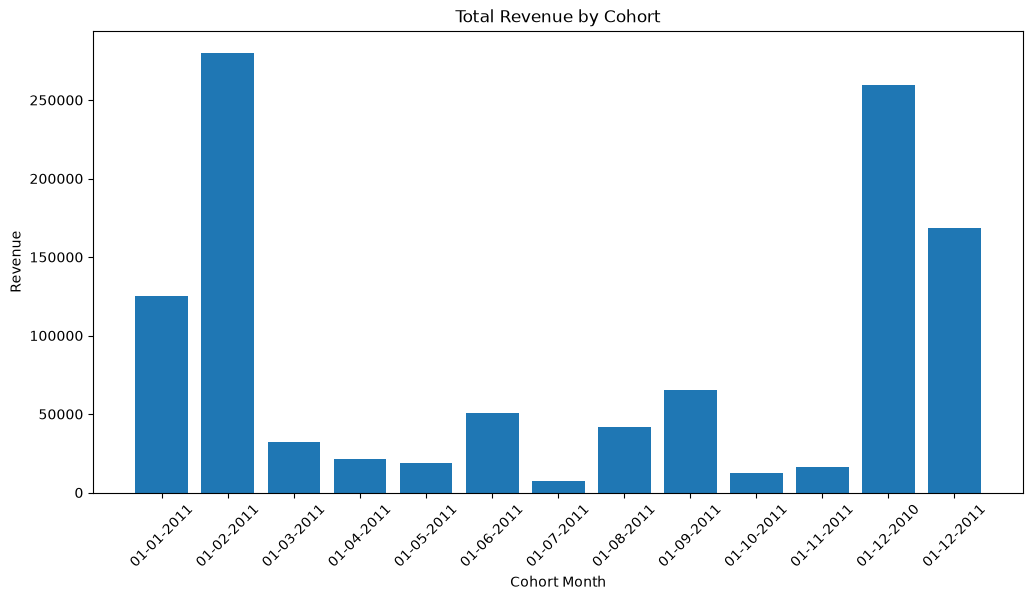

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(
    customer_cohort_revenue['CohortMonth'].astype(str),
    customer_cohort_revenue['TotalRevenue']
)
plt.title('Total Revenue by Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [16]:
country_revenue = (
    df.groupby('Country')['TotalRevenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

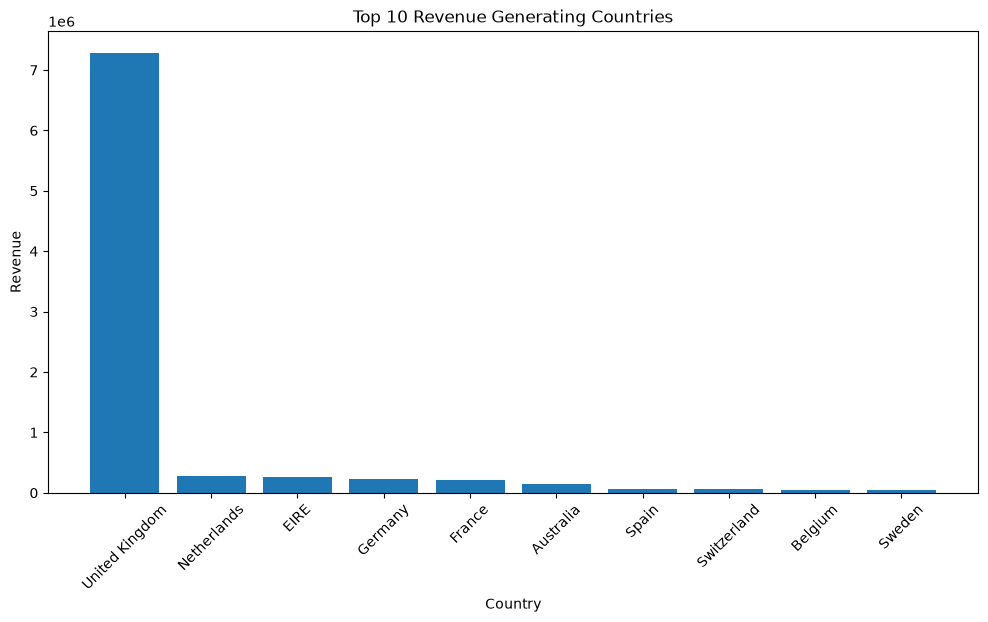

In [17]:
plt.figure(figsize=(12, 6))
plt.bar(
    country_revenue['Country'],
    country_revenue['TotalRevenue']
)
plt.title('Top 10 Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Validation of Cohort Revenue Segmentation

## Objective
Validate the customer-level revenue aggregation generated using CohortMonth and CustomerID.

## Validation Checks Performed
1. Examined the first few rows of the aggregated dataset.
2. Verified the dataset dimensions.
3. Checked data types of all columns.
4. Identified missing values.
5. Confirmed there were no duplicate customer-cohort combinations.
6. Generated summary statistics for TotalRevenue.

## Result
The aggregated dataset was successfully validated and found suitable for further analyses such as Average Order Value (AOV) computation and Customer Lifetime Value (CLTV) estimation.